In [2]:
#pip install geostatspy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import pandas as pd   # abreviate to limit number of keystrokes with typing
import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree # dendrograms
from sklearn.cluster import KMeans # For k-means
import seaborn as sns
#import scipy
import subprocess
import geostatspy.GSLIB as GSLIB                       # GSLIB utilies, visualization and wrapper
import geostatspy.geostats as geostats                 # GSLIB methods convert to Python   

ModuleNotFoundError: No module named 'numba'

In [2]:
# need the following to run Datamine. This is the path to the folder dmstudio.
# This is temporary. For a more permanent solution, you need to add the path to the PATH outside of the notebook.
sys.path.append('C:\\Users\\KathleenBody')

In [3]:

import dmstudio.dmcommands as dmcommands
import dmstudio.dmfiles
dmc = dmcommands.init(version='StudioRM')
dmf = dmstudio.dmfiles.init(version='StudioRM')
import dmstudio.special as special

# There may be an error message for SH's original scrips. As of 2024/09/, it is a warning, so dmcommands still run.

pyrpa module not found, only available to SLR employees


In [4]:
#cmd = dmcommands.init(version='StudioRM')

In [6]:
fileObject = open('C:\\Users\\KathleenBody\\OneDrive - Red Bush Geoservices (Pty) Ltd\\GSLIB_Master\\Data\\oilsands.dat')

number_of_lines = 200
for i in range(number_of_lines): #             Print the first number_of_lines lines of fileObject.
    line = fileObject.readline()
    print(line)

Oil Sands Data

8

Drillhole Number

East, m

North, m

Elevation, m

Bitumen, percent

Fines, percent

Chlorides, ppm

Facies Code

  2 1245.00 10687.09 257.50   7.378  28.784   -9.00 -9

  2 1245.00 10687.09 254.50   9.176  22.897   -9.00 -9

  2 1245.00 10687.09 251.50  11.543  15.144   -9.00 -9

  2 1245.00 10687.09 248.50   6.808  30.598   -9.00 -9

  2 1245.00 10687.09 245.50  10.657  18.011   -9.00 -9

  2 1245.00 10687.09 242.50  12.009  13.576   -9.00 -9

  2 1245.00 10687.09 239.50  12.687  11.401   -9.00 -9

  2 1245.00 10687.09 236.50  13.040  10.224   -9.00 -9

  2 1245.00 10687.09 233.50  13.912   7.330   -9.00 -9

  2 1245.00 10687.09 230.50  13.354  10.085   -9.00 -9

  2 1245.00 10687.09 227.50  14.914   5.308   -9.00 -9

  2 1245.00 10687.09 224.50  14.906   5.809   -9.00 -9

  2 1245.00 10687.09 221.50  10.173  19.632   -9.00 -9

  2 1245.00 10687.09 218.50  14.387   7.178   -9.00 -9

  2 1245.00 10687.09 215.50  13.784   7.784   -9.00 -9

  2 1245.00 10687.09 212.50

The file above is in a format known as GEOEAS. It's an old US government data format that GSLIB and other software use.  
>The first row is the dataset name.  <br>
>The second row is the number of columns,  N. <br>
>The next N rows are the column names. <br>
>The data is listed in SPACE delimited columns. <br>

The geostatspy package by Michael Pyrcz has a function that converts this type of file to a DataFrame with a header row and data columns.  The DataFrame can then be exported as a CSV or text file for use in other software.  

Otherwise, you have two options:<br>
1. Reformat the file in Excel. Delete the first two lines, create column labels in the first row, and save the data as a CSV formatted file. This is time-efficient for small data sets.
2. Edit the file in Python and write a new text file. This option is more work than the first option but necessary for large datasets. Since someone has already written code to do this, make your life easier by using geostatspy.

From GSLIB call GSLIB2Dataframe(filename)<br>

#### **************************************************************************************************************************************************

NOTE on data formats.
In the file above, yYou will notice that the borehole name is a number. This is required for use in GSLIB because that ishowy it was set up.You will need a copy of the data in this format if you use any of the GSLIB executables in your scripat. For any other softwar,e check the formats. ForPpanadsDdatFframe, Python, ands Datamine, borehole names can be strings. I prefer to keep names as strings and numbers as numbers. To some exten, this is a personal preference, but it has the advantages of keeping datatypes well defined throughout the code.
#### 

**************************************************************************************************************************************************¶

In [7]:
input_data = GSLIB.GSLIB2Dataframe('C:\\Users\\KathleenBody\\OneDrive - Red Bush Geoservices (Pty) Ltd\\GSLIB_Master\\Data\\oilsands.dat')
input_data

,Drillhole,"East,","North,","Elevation,","Bitumen,","Fines,","Chlorides,",Facies
0,2.0,1245.00,10687.09,257.5,7.378,28.784,-9.0,-9.0
1,2.0,1245.00,10687.09,254.5,9.176,22.897,-9.0,-9.0
2,2.0,1245.00,10687.09,251.5,11.543,15.144,-9.0,-9.0
3,2.0,1245.00,10687.09,248.5,6.808,30.598,-9.0,-9.0
4,2.0,1245.00,10687.09,245.5,10.657,18.011,-9.0,-9.0
...,...,...,...,...,...,...,...,...
5803,280.0,945.09,6586.30,230.5,6.920,33.100,-9.0,-9.0
5804,281.0,974.80,6577.70,239.5,6.100,48.500,-9.0,-9.0
5805,281.0,974.80,6577.70,236.5,11.392,14.500,-9.0,-9.0
5806,281.0,974.80,6577.70,233.5,9.010,32.483,-9.0,-9.0


In [8]:
input_data.dtypes

Drillhole     float64
East,         float64
North,        float64
Elevation,    float64
Bitumen,      float64
Fines,        float64
Chlorides,    float64
Facies        float64
dtype: object

In [9]:
df = input_data
# Change the datatype of the drillhole name to eliminate the decimal
df['Drillhole'] = df['Drillhole'].astype('Int64')
#change the data type to a string
df['Drillhole'] = df['Drillhole'].astype('str')
# Create a new column calld BHID and add a prefix to the drillhole name
df['BHID'] = 'BH' + df['Drillhole']
print(df.dtypes)
print(df)

Drillhole      object
East,         float64
North,        float64
Elevation,    float64
Bitumen,      float64
Fines,        float64
Chlorides,    float64
Facies        float64
BHID           object
dtype: object
     Drillhole    East,    North,  Elevation,  Bitumen,  Fines,  Chlorides,  \
0            2  1245.00  10687.09       257.5     7.378  28.784        -9.0   
1            2  1245.00  10687.09       254.5     9.176  22.897        -9.0   
2            2  1245.00  10687.09       251.5    11.543  15.144        -9.0   
3            2  1245.00  10687.09       248.5     6.808  30.598        -9.0   
4            2  1245.00  10687.09       245.5    10.657  18.011        -9.0   
...        ...      ...       ...         ...       ...     ...         ...   
5803       280   945.09   6586.30       230.5     6.920  33.100        -9.0   
5804       281   974.80   6577.70       239.5     6.100  48.500        -9.0   
5805       281   974.80   6577.70       236.5    11.392  14.500        -9.0  

Notice that the column names contain commas; these are unnecessary and will cause errors when exporting to CSV formats.  It is best to delete them. <br> The order of the columns makes the DataFrame difficult to read. Grouping the different kinds of data makes it easier to read and manipulate the DataFrame.  Why this is useful will become clearer later.<br>
To edit the column names, create a dictionary {'A': 'A1', 'B': 'B1'} and map the old to new names.<br>
To reorder the columns, create a list ['A', 'B'] with the columns in the new order.

In [10]:
#rename the columns
df.rename(columns={'East,': 'East', 'North,': 'North', 'Elevation,': 'Elevation', 'Bitumen,': 'Bitumen', 'Fines,': 'Fines', 'Chlorides,': 'Chlorides' }, inplace=True)
# reorder the columns
df = df[['BHID', 'East', 'North', 'Elevation', 'Fines', 'Bitumen', 'Chlorides', 'Facies']]
df

,BHID,East,North,Elevation,Fines,Bitumen,Chlorides,Facies
0,BH2,1245.00,10687.09,257.5,28.784,7.378,-9.0,-9.0
1,BH2,1245.00,10687.09,254.5,22.897,9.176,-9.0,-9.0
2,BH2,1245.00,10687.09,251.5,15.144,11.543,-9.0,-9.0
3,BH2,1245.00,10687.09,248.5,30.598,6.808,-9.0,-9.0
4,BH2,1245.00,10687.09,245.5,18.011,10.657,-9.0,-9.0
...,...,...,...,...,...,...,...,...
5803,BH280,945.09,6586.30,230.5,33.100,6.920,-9.0,-9.0
5804,BH281,974.80,6577.70,239.5,48.500,6.100,-9.0,-9.0
5805,BH281,974.80,6577.70,236.5,14.500,11.392,-9.0,-9.0
5806,BH281,974.80,6577.70,233.5,32.483,9.010,-9.0,-9.0


The DataFrame now has the drillhole names in the first column, as strings.<br>
The coordinates are in the first three columns. <br>
The qualities are in the next three columns. <br>
The geology is in the last column.

In [11]:
# Check what is in the file.
# basic stats
df.describe()

,East,North,Elevation,Fines,Bitumen,Chlorides,Facies
count,5808.000000,5808.000000,5808.000000,5808.000000,5808.000000,5808.000000,5808.000000
mean,1946.087970,7682.221741,228.315599,28.707298,7.708852,103.139353,40.099862
std,797.529936,1546.319434,21.478426,21.247085,5.136709,286.545409,24.556658
min,567.410000,5010.700000,146.500000,0.861000,0.000000,-9.000000,-9.000000
25%,1348.590000,6499.410000,212.500000,10.166000,2.877750,-9.000000,50.000000
50%,1708.200000,7280.700000,230.500000,24.453000,7.480000,5.400000,50.000000
75%,2449.000000,8775.300000,245.500000,42.823250,12.666000,63.900000,50.000000
max,3875.500000,10990.800000,275.500000,86.777000,18.428000,2602.000000,70.000000


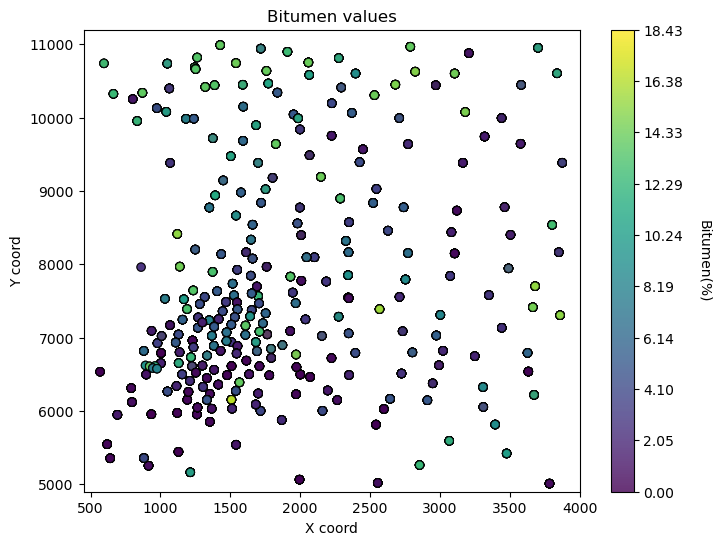

In [12]:
# plot a location map

xmin=450
xmax=4000
ymin=4900
ymax = 11200
bitmin=0
bitmax=df['Bitumen'].max()   # if you do not know the maximum
cmap = plt.cm.viridis                    #colour map https://matplotlib.org/stable/users/explain/colors/colormaps.html  pick something younlike

GSLIB.locmap(df,'East', 'North', 'Bitumen',xmin, xmax, ymin, ymax, bitmin, bitmax, 'Bitumen values', 'X coord', 'Y coord', 'Bitumen(%)', cmap, 'Loc Map Bitumen')   # scales are not the same om both axes

Create a collar file, an assay file and a lithology file. This will be used to create a Datamine desurveyed drillhole file.<br>

A separate Assay and Lithology file is unnecessary in this case as all the intervals are the same, but we want to learn a process for more complex files.<br>

Extract the BHID and coordinates to create a collar file. Because these are vertical holes, the x and y are the same, so we need to extract one row for each borehole.  This method is unsuitable for deviated holes; you should already have the collar file.  If not, it gets complicated.<br>
All the borehole depths are given as elevations.  These need to be converted to depths. The easiest way is to create a datum at a higher elevation than the highest borehole collar and subtract the elevations. This will give a depth below the datum, and the collar elevation can be assumed to be the datum.  This ensures the borehole positions are spatially correct. The desurveyed file will have a gap between the datum and the first sample, which can be coded as waste.

In [13]:
# Transform elevations into depths
max_elev = df['Elevation'].max()
print(max_elev)

275.5


In [14]:
# choose a datum
#datum = 300     # alt  datum = (df['Elevation'].max() // 100 + 1)*100    gives nearest 100m higher than max_elevation
#df['Depth'] = 300 - df['Elevation']

# OR

# alt  datum = (df['Elevation'].max() // 100 + 1)*100    gives nearest 100m higher than max_elevation and subtracts elevation
df['Depth'] = (df['Elevation'].max() // 100 + 1)*100 - df['Elevation']


# create FROM/TO columns; each sample is 3 (ft? its Canada) long
df['FROM'] = df['Depth'] -1.5
df['TO'] = df['Depth'] +1.5
df


,BHID,East,North,Elevation,Fines,Bitumen,Chlorides,Facies,Depth,FROM,TO
0,BH2,1245.00,10687.09,257.5,28.784,7.378,-9.0,-9.0,42.5,41.0,44.0
1,BH2,1245.00,10687.09,254.5,22.897,9.176,-9.0,-9.0,45.5,44.0,47.0
2,BH2,1245.00,10687.09,251.5,15.144,11.543,-9.0,-9.0,48.5,47.0,50.0
3,BH2,1245.00,10687.09,248.5,30.598,6.808,-9.0,-9.0,51.5,50.0,53.0
4,BH2,1245.00,10687.09,245.5,18.011,10.657,-9.0,-9.0,54.5,53.0,56.0
...,...,...,...,...,...,...,...,...,...,...,...
5803,BH280,945.09,6586.30,230.5,33.100,6.920,-9.0,-9.0,69.5,68.0,71.0
5804,BH281,974.80,6577.70,239.5,48.500,6.100,-9.0,-9.0,60.5,59.0,62.0
5805,BH281,974.80,6577.70,236.5,14.500,11.392,-9.0,-9.0,63.5,62.0,65.0
5806,BH281,974.80,6577.70,233.5,32.483,9.010,-9.0,-9.0,66.5,65.0,68.0


In [15]:
# Create a new DataFrame with drillhole name, X and Y coordinates and add the datum as the Z collar coordinate.
collars = df[['BHID', 'East', 'North']]
collars['Datum'] = 300
collars

# The interpreter returns an error/warning message which can be ignored for this exercise.

C:\Users\KathleenBody\AppData\Local\Temp\ipykernel_35132\2173480381.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  collars['Datum'] = 300


,BHID,East,North,Datum
0,BH2,1245.00,10687.09,300
1,BH2,1245.00,10687.09,300
2,BH2,1245.00,10687.09,300
3,BH2,1245.00,10687.09,300
4,BH2,1245.00,10687.09,300
...,...,...,...,...
5803,BH280,945.09,6586.30,300
5804,BH281,974.80,6577.70,300
5805,BH281,974.80,6577.70,300
5806,BH281,974.80,6577.70,300


In [16]:
# remove duplicates with the same coordinates ie. keep the first row for each drillhole
collars = collars.drop_duplicates(subset=['East', 'North'], keep='first')
collars

# Note that the row indices do not change - leave them as they were in the original for now, and do not reset them.

,BHID,East,North,Datum
0,BH2,1245.00,10687.09,300
18,BH3,1262.50,10821.30,300
29,BH4,1319.91,10419.50,300
42,BH5,662.91,10325.70,300
54,BH6,870.50,10339.91,300
...,...,...,...,...
5790,BH277,892.80,6622.20,300
5793,BH278,922.50,6609.70,300
5797,BH279,959.91,6614.41,300
5800,BH280,945.09,6586.30,300


In [17]:
# Create assay and geology files

assays = df[['BHID', 'FROM', 'TO', 'Bitumen', 'Fines', 'Chlorides']]
geology = df[['BHID', 'FROM', 'TO', 'Facies']] 
print(assays.head(10))
print(geology.head(10))

  BHID  FROM    TO  Bitumen   Fines  Chlorides
0  BH2  41.0  44.0    7.378  28.784       -9.0
1  BH2  44.0  47.0    9.176  22.897       -9.0
2  BH2  47.0  50.0   11.543  15.144       -9.0
3  BH2  50.0  53.0    6.808  30.598       -9.0
4  BH2  53.0  56.0   10.657  18.011       -9.0
5  BH2  56.0  59.0   12.009  13.576       -9.0
6  BH2  59.0  62.0   12.687  11.401       -9.0
7  BH2  62.0  65.0   13.040  10.224       -9.0
8  BH2  65.0  68.0   13.912   7.330       -9.0
9  BH2  68.0  71.0   13.354  10.085       -9.0
  BHID  FROM    TO  Facies
0  BH2  41.0  44.0    -9.0
1  BH2  44.0  47.0    -9.0
2  BH2  47.0  50.0    -9.0
3  BH2  50.0  53.0    -9.0
4  BH2  53.0  56.0    -9.0
5  BH2  56.0  59.0    -9.0
6  BH2  59.0  62.0    -9.0
7  BH2  62.0  65.0    -9.0
8  BH2  65.0  68.0    -9.0
9  BH2  68.0  71.0    -9.0


In [18]:
#Check the assay file for content
# The drillhole name is omitted because it is a string.  This is a good way to check the datatypes.  Any columns with strings in any row will not be returned.
assays.describe()

,FROM,TO,Bitumen,Fines,Chlorides
count,5808.000000,5808.000000,5808.000000,5808.000000,5808.000000
mean,70.184401,73.184401,7.708852,28.707298,103.139353
std,21.478426,21.478426,5.136709,21.247085,286.545409
min,23.000000,26.000000,0.000000,0.861000,-9.000000
25%,53.000000,56.000000,2.877750,10.166000,-9.000000
50%,68.000000,71.000000,7.480000,24.453000,5.400000
75%,86.000000,89.000000,12.666000,42.823250,63.900000
max,152.000000,155.000000,18.428000,86.777000,2602.000000


In [19]:
# Check number of samples in each facies.

counts = geology['Facies'].value_counts()
#or
#grouped_data=geology['Facies']
#ps = pd.Series([i for i in grouped_data])
#counts = ps.value_counts()

print(counts)
#Facies 50 is the most common unit and undefined has a large number of samples

Facies
 50.0    3465
-9.0     1132
 60.0    1006
 40.0     124
 61.0      52
 31.0      10
 69.0       7
 30.0       6
 70.0       5
 23.0       1
Name: count, dtype: int64


Files can now be exported to data or other geological modelling packages for desurveying.

In [20]:
#export files to csv format
collars.to_csv('C:\\Database\\Oil_Sands_2024\\collars_py.csv')
assays.to_csv('C:\\Database\\Oil_Sands_2024\\assays_py.csv')
geology.to_csv('C:\\Database\\Oil_Sands_2024\\geology_py.csv')



## ***************************************************************************************************************************************************
## Import files onto Datamine - Interactive

The following process converts files to Datamine table format and import the files into Datamine using a Python script. If you have set up your Datamine project to automatically add files to your project, you will not need to import the dm files manually.<br>


Requirements:<br>
1. Datamine must be installed on the local computer.
2. The full PATH of the Data Converter, *DataConverter.exe*. A Datamine license is not required to be active; this is a standalone file.
3. The full PATH  of the Table Editor, *TableEditorME.exe, or TableEditor.exe* file. A Datamine license is not required to be active; this is a standalone file.
4. To run HOLES3D and COMPDH, Datamine must be running on your local computer and opened to the appropriate Project.<br>

Import the CSV files using the Data Converter.  This allows for changes to be made to the column headers and correctly formats the dm files.

You will need to choose the input file and supply a name for the "export" file.  The input file is the CSV file, and the export file is the dm file. If no file is specified for config, the config file is created (recommended for simple cases).
*If you need to overwrite an existing file, check the box under export 'Overwrite the existing file'* otherwise the export will terminate and close without warning and not save the export (Datamine issue).




In [21]:
# To import files, use the code below. This opens the Data Converter wizard.  You can import as many files as you want. Then, close the Data Converter to terminate the subprocess.

subprocess.run(["C:\\Program Files\\Datamine\\Data Converter\\DataConverter.exe"])   # interactively convert files into Datamine format.

#The folder for the new file must be specified-full path  seen net code block for an example.

CompletedProcess(args=['C:\\Program Files\\Datamine\\Data Converter\\DataConverter.exe'], returncode=2)

In [22]:
#To edit a Datamine table file, use the following:
#Call the Table Editor and open the file.

filename = "C:\\Database\\Oil_Sands_2024\\collars_py.dm"

subprocess.run(["C:\\Program Files\\Datamine\\Table Editor\\TableEditorME.exe", filename])   # or
#subprocess.run(["C:\\Program Files\\Datamine\\Table Editor\\TableEditor.exe", filename])

#The code will terminate when the Table Editor is closed

CompletedProcess(args=['C:\\Program Files\\Datamine\\Table Editor\\TableEditorME.exe', 'C:\\Database\\Oil_Sands_2024\\collars_py.dm'], returncode=0)

### **IF you are going to run this regularly and have the same file structure always,  Set up an INPFIL import routine**

## ***************************************************************************************************************************************************
### Access Datamine to run some Datamine subprocesses.<br>
Put the folder *dmstudio* in the project folder where this script is stored.  Use
#os.getcwd() # to find the folder.

There are more efficient ways to run this, but they require a set-up outside of this script.

In [23]:
import win32com.client as client


In [24]:
oScript = client.Dispatch("Datamine.StudioRM.Application")  # connect to Datamine.  Ensure Datamine is running and the Project is opened before running this block.
# Sometimes, DM does not initialize. The easiest way to deal with this is to restart the computer.  It clears the cache, which I think is where the problem is.
oScript

<COMObject Datamine.StudioRM.Application>

In [25]:
#Change the working directory to the Datamine project folder.  The subprocesses look in the project folder. If you want to access different folders, you will need to set up variables for each file and call the variables. Datamine doesn't work well with this setup.
os.chdir('C:\\Database\\Oil_Sands_2024\\')
os.getcwd()

'C:\\Database\\Oil_Sands_2024'

In [31]:
dmc.holes3d(collar_i='collars_py',
           samples_i=['assays_py', 'geology_py'],
           survey_i='optional',
           out_o='holes_py3', 
           holesmry_o='holes_py3_smry', 
           errors_o='holes_py3_err',
           bhid_f='BHID',
           xcollar_f='XCOLLAR',
           ycollar_f='YCOLLAR',
           zcollar_f='ZCOLLAR',
           from_f='FROM',
           to_f='TO',
           survsmth_p='1.0',
           dipmeth_p='0.0',
)

filename = "C:\\Database\\Oil_Sands_2024\\holes_py3_err.dm"
subprocess.run(["C:\\Program Files\\Datamine\\Table Editor\\TableEditorME.exe",filename])
filename = "C:\\Database\\Oil_Sands_2024\\holes_py3_smry.dm"
subprocess.run(["C:\\Program Files\\Datamine\\Table Editor\\TableEditorME.exe",filename])
filename = "C:\\Database\\Oil_Sands_2024\\holes_py3.dm"
subprocess.run(["C:\\Program Files\\Datamine\\Table Editor\\TableEditorME.exe",filename])

holes3d  &collar=collars_py &sample1=assays_py  &sample2=geology_py  &out=holes_py3 &holesmry=holes_py3_smry &errors=holes_py3_err *bhid=BHID *xcollar=XCOLLAR *ycollar=YCOLLAR *zcollar=ZCOLLAR *from=FROM *to=TO @survsmth=1.0 @endpoint=0 @dipmeth=0.0 @print=0


CompletedProcess(args=['C:\\Program Files\\Datamine\\Table Editor\\TableEditorME.exe', 'C:\\Database\\Oil_Sands_2024\\holes_py3.dm'], returncode=0)

In [32]:
dmc.compdh(in_i='holes_py3', 
          out_o='holes_comp_py5', 
          bhid_f='BHID', 
          from_f='FROM', 
          to_f='TO', 
          zone_f='Facies', 
          interval_p='100', 
          mingap_p='0.01', maxgap_p=0, 
          mincomp_p=0.01,  
          start_p=0.0, mode_p=1.0, 
          print_p=0.0)
filename = "C:\\Database\\Oil_Sands_2024\\holes_comp_py5.dm"
subprocess.run(["C:\\Program Files\\Datamine\\Table Editor\\TableEditorME.exe",filename])

CompletedProcess(args=['C:\\Program Files\\Datamine\\Table Editor\\TableEditorME.exe', 'C:\\Database\\Oil_Sands_2024\\holes_comp_py5.dm'], returncode=0)

In [37]:
#dmc.export()    #calls up the export menu  (if it does not show up immediately click on the Datamine window)
#Window closes on export and code terminates

In [33]:
df_valid = pd.read_csv("C:\\Database\\Oil_Sands_2024\\holes_comp_py3.csv")
df_valid.tail(30)

,BHID,FROM,TO,Facies,Bitumen,Fines,Chloride,X,Y,Z,LENGTH,RADIUS,A0,B0,C0
576,BH86,50,98,50,9.532937,25.170938,-9.000000,3859.91,7306.70,226.0,48,1,0,90,0
577,BH87,44,110,50,9.812091,18.353000,-9.000000,3784.20,5010.70,223.0,66,1,0,90,0
578,BH87,110,119,60,1.834667,59.610000,-9.000000,3784.20,5010.70,185.5,9,1,0,90,0
579,BH88,32,35,40,0.587000,61.835000,39.900000,1908.59,10899.20,266.5,3,1,0,90,0
580,BH88,35,92,50,11.344316,36.984579,49.318421,1908.59,10899.20,236.5,57,1,0,90,0
581,BH89,38,92,50,5.982722,36.237889,269.179444,2275.59,10813.41,235.0,54,1,0,90,0
582,BH9,38,83,-9,0.773933,50.372800,-9.000000,1181.91,9985.70,239.5,45,1,0,90,0
583,BH90,38,89,50,6.499412,12.609529,280.100000,2058.59,10754.09,236.5,51,1,0,90,0
584,BH90,89,98,60,13.748333,4.043333,207.066667,2058.59,10754.09,206.5,9,1,0,90,0
585,BH91,35,83,50,7.064125,39.277813,156.331250,1588.50,10450.30,241.0,48,1,0,90,0


In [35]:
# Group by BHID and Facies, and count the occurrences
grouped_data = df_valid.groupby(['BHID', 'Facies']).size().reset_index(name='count')

# Filter to show only groups where count > 1
filtered_data = grouped_data[grouped_data['count'] > 1]

print(filtered_data)

Empty DataFrame
Columns: [BHID, Facies, count]
Index: []


In the original data!

      BHID  Facies  count
253  BH198      50      2
254  BH198      60      2
282  BH209      50      2
331  BH228      50      2
332  BH228      60      2
391  BH249      50      2
577   BH87      50      2
578   BH87      60      2

NOTE that the above boreholes have more than one instance of each facies. We are expecting continuous zones resulting in one instance after compositing. This data needs to be checked and errors corrected.

Open the Datam (holes_py3.dm )ine file and correct the data- do not change the original.d  Holes_py3 is the geology file used going forward.at file!

209 and 248 have breaks in the sequence = these will affect the modelling using implicit modelling as they are seen as different segments. Segments will need to be added with absent values for the q.

Correct the Facies code in the other 3 holes.ualities

After correcting  5 boreholes no errors.

In [36]:
filename = "C:\\Database\\Oil_Sands_2024\\holes_py3.dm"

subprocess.run(["C:\\Program Files\\Datamine\\Table Editor\\TableEditorME.exe",filename])

#209 and 249 have breaks in the sequence = these will affect the modelling using implicit modelling as they are seen as different segments. Segments will need to be added with absent values for the q  qualities.
# the other  three boreholes have errors  BH198,??  BH87
# rerun 


dmc.compdh(in_i='holes_py3', 
          out_o='holes_comp_py3', 
          bhid_f='BHID', 
          from_f='FROM', 
          to_f='TO', 
          zone_f='Facies', 
          interval_p='100', 
          mingap_p='0.01', maxgap_p=0, 
          mincomp_p=0.01,  
          start_p=0.0, mode_p=1.0, 
          print_p=0.0)
filename = "C:\\Database\\Oil_Sands_2024\\holes_comp_py3.dm"
subprocess.run(["C:\\Program Files\\Datamine\\Table Editor\\TableEditorME.exe",filename])

CompletedProcess(args=['C:\\Program Files\\Datamine\\Table Editor\\TableEditorME.exe', 'C:\\Database\\Oil_Sands_2024\\holes_comp_py3.dm'], returncode=0)

In [8]:
# Close Datamine when you are finished.  This makes sure the COM object is released.
oScript.Quit()   #This will open the save project dialog and you can quit Datamine.

## Next Steps

Generally, the next step is to create the geological model.  The Facies have been set up so that the composite file has only one composite for each facies.  These can be used to create wireframes.  From the data, there are two Facies with most of the data (50, 60) and undefined facies -9. Due to the wide spacing in the north and east of the data set, there will likely be holes in the wireframes. It will be necessary to manually edit the surfaces if the implicit modelling function is used.   Using Leapfrog will probably give a better result.  Either way, the Wireframe/surface creation is done outside of Python for this exercise. <br>

Facies are numbered from smallest=youngest to largest = oldest.  From the data, there are two Facies with most of the data (50, 60) and undefined facies -9. The only possible surfaces with enough points to model are 40, 50 and 60.  These are sediments with most of the Bitumen contained in Facies 50.  However, Facies 50 is bimodal with high and low bitumen subfacies.  Once the top and base of facies 50 are modelled, the distribution of the bitumen/fines needs to be estimated.  The Chlorides are only sporadically analysed and insufficient in quantity to be used in modelling overall.
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [ ]:
Part 2  Will use cluster analysis to mdoel facies 50 in more detail.  

In [1]:
client.Dispatch('Excel.Application')

NameError: name 'client' is not defined